# Audit Independen Klaim Return 25% Berbasis IHSG

Notebook Python ini dirancang untuk dijalankan bertahap di **Kaggle Code**. Program mengunduh data IHSG secara otomatis, memeriksa integritas data, mencegah *data leakage*, melatih model, membentuk sinyal transaksi, menghitung friksi, menguji SHAP, menilai stabilitas, lalu menyusun rekomendasi terbatas untuk Komite Investasi.

**Pertanyaan audit utama:** Apakah klaim return tahunan 25 persen tetap bertahan setelah validasi di luar sampel, biaya transaksi, pajak, *spread*, *slippage*, proksi likuiditas, dampak pasar, beberapa *seed*, dan beberapa kondisi pasar?

**Batas penting:** IHSG adalah indeks, bukan aset yang dapat dibeli langsung. Hasil transaksi pada notebook ini merupakan validasi model berbasis indeks. Sebelum investasi nyata, tim wajib mengganti asumsi eksekusi dengan data instrumen yang benar-benar diperdagangkan, misalnya ETF atau kontrak berjangka yang relevan.

In [1]:
# TAHAP 0A - Instalasi pustaka di Kaggle
# Aktifkan Internet pada Settings Kaggle sebelum menjalankan sel ini.
%pip install -q "yfinance>=0.2.54" "shap>=0.46.0"

print("Instalasi selesai. Jika kernel meminta restart, pilih Restart Session lalu jalankan ulang notebook.")

Note: you may need to restart the kernel to use updated packages.
Instalasi selesai. Jika kernel meminta restart, pilih Restart Session lalu jalankan ulang notebook.


In [2]:
# TAHAP 0B - Impor, konfigurasi, dan reproduksibilitas
import os
import sys
import json
import math
import random
import time
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import shap

from IPython.display import display, Markdown
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

CONFIG = {
    "ticker": "^JKSE",
    "start_date": "2010-01-01",
    "end_date": (pd.Timestamp.now(tz="UTC").normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    "claim_annual_return": 0.25,
    "train_fraction": 0.70,
    "validation_fraction": 0.15,
    "annual_trading_days": 252,
    "capital_idr": 100_000_000,
    "probability_threshold_grid": [0.50, 0.525, 0.55, 0.575, 0.60, 0.625],
    "seeds": [11, 42, 73, 101, 202],
}

COST_BPS = {
    "komisi_beli_jual": 24.0,
    "pajak_penjualan": 10.0,
    "levy_bursa": 4.0,
    "spread": 3.0,
    "slippage": 4.0,
    "penalti_likuiditas": 2.0,
    "dampak_pasar": 2.0,
}

OUTPUT_DIR = Path("/kaggle/working/ihsg_audit_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config_table = pd.DataFrame([
    ["Ticker data", CONFIG["ticker"]],
    ["Periode awal", CONFIG["start_date"]],
    ["Periode akhir eksklusif", CONFIG["end_date"]],
    ["Klaim return tahunan", f'{CONFIG["claim_annual_return"]:.0%}'],
    ["Modal skenario", f'Rp{CONFIG["capital_idr"]:,.0f}'],
    ["Total biaya dasar", f'{sum(COST_BPS.values()):.1f} bps per transaksi pulang-pergi'],
    ["Seed utama", SEED],
], columns=["Parameter", "Nilai"])
display(config_table)
print(f"Output run akan tersimpan di: {OUTPUT_DIR}")

,Parameter,Nilai
0,Ticker data,^JKSE
1,Periode awal,2010-01-01
2,Periode akhir eksklusif,2026-08-03
3,Klaim return tahunan,25%
4,Modal skenario,"Rp100,000,000"
5,Total biaya dasar,49.0 bps per transaksi pulang-pergi
6,Seed utama,42


Output run akan tersimpan di: /kaggle/working/ihsg_audit_outputs


## Tahap 1. Algoritma Program

1. Tetapkan ticker IHSG, periode data, klaim 25 persen, biaya, modal, dan *seed*.
2. Unduh OHLCV harian IHSG secara otomatis dari Yahoo Finance melalui `yfinance`.
3. Audit struktur data, tanggal, nilai hilang, duplikasi, harga tidak logis, dan keterbaruan data.
4. Bersihkan data tanpa mengisi harga masa depan dan simpan data bersih.
5. Bentuk fitur teknikal hanya dari informasi yang tersedia sampai penutupan hari ke-t.
6. Tetapkan target berdasarkan return intraday hari ke-(t+1), dari harga pembukaan ke penutupan berikutnya.
7. Bagi data secara kronologis menjadi latih, validasi, dan uji. Jangan lakukan pengacakan.
8. Latih model pada data latih. Pilih ambang probabilitas hanya pada data validasi setelah biaya.
9. Latih ulang model pada gabungan data latih dan validasi. Nilai satu kali pada data uji.
10. Bentuk sinyal, hitung return kotor, lalu kurangi komisi, pajak, *spread*, *slippage*, penalti likuiditas, dan dampak pasar.
11. Hitung CAGR, volatilitas, rasio Sharpe, *maximum drawdown*, jumlah transaksi, dan eksposur.
12. Uji stabilitas pada beberapa biaya, ambang, tahun, rezim pasar, dan *seed*.
13. Hitung SHAP. Rekonstruksi keluaran model dan ukur konsistensi peringkat fitur lintas *seed*.
14. Jalankan pemeriksaan bug dan logika. Susun keputusan audit serta rekomendasi uji coba terbatas.

**Output tahap:** tabel arsitektur audit ditampilkan oleh sel berikutnya.

## Tahap 2. Pseudocode

```text
MULAI
  TETAPKAN konfigurasi, biaya, klaim_return = 25%, dan beberapa seed
  UNDUH data IHSG berdasarkan ticker dan tanggal
  JIKA data kosong ATAU kolom wajib tidak lengkap: HENTIKAN dengan pesan diagnostik

  URUTKAN data berdasarkan tanggal
  HAPUS duplikasi, nilai kosong wajib, nilai tak hingga, dan harga tidak logis
  CATAT semua perubahan jumlah baris

  HITUNG fitur dari data sampai hari t
  HITUNG return_eksekusi dari Open(t+1) ke Close(t+1)
  BENTUK target arah return_eksekusi
  HAPUS baris awal yang belum memiliki jendela fitur

  BAGI data kronologis menjadi TRAIN, VALIDASI, TEST
  LATIH model pada TRAIN
  UNTUK setiap ambang kandidat:
      BENTUK sinyal pada VALIDASI
      HITUNG return bersih setelah seluruh friksi
      PILIH ambang berdasarkan Sharpe bersih, dengan jumlah transaksi minimum

  LATIH ULANG model pada TRAIN + VALIDASI
  PREDIKSI probabilitas TEST satu kali
  HITUNG metrik klasifikasi
  HITUNG return kotor, return bersih, CAGR, Sharpe, dan MDD

  UJI biaya, ambang, periode, rezim, dan seed
  HITUNG SHAP dan residual rekonstruksi
  UJI kestabilan peringkat SHAP lintas seed
  JALANKAN assertions kebocoran, urutan tanggal, biaya, dan ekuitas

  JIKA return bersih < 25% ATAU stabilitas lemah:
      KEPUTUSAN = klaim belum tervalidasi
  JIKA semua kontrol utama lolos:
      KEPUTUSAN = hanya layak uji coba terbatas, bukan investasi penuh
  SIMPAN tabel, grafik, parameter, dan ringkasan eksekutif
SELESAI
```

In [3]:
# TAHAP 2 - Tabel alur yang dapat ditelusuri
pipeline_table = pd.DataFrame([
    [1, "Akuisisi", "Yahoo Finance via yfinance", "raw_ihsg.csv, metadata sumber"],
    [2, "Validasi data", "OHLCV mentah", "quality_report.csv, grafik harga"],
    [3, "Rekayasa fitur", "Data bersih sampai t", "feature_dataset.csv, heatmap"],
    [4, "Pemisahan", "Indeks waktu", "tabel train-valid-test"],
    [5, "Pemodelan", "Train dan validasi", "metrik klasifikasi, confusion matrix"],
    [6, "Backtest", "Sinyal test dan biaya", "kurva ekuitas, tabel kinerja"],
    [7, "Validasi SHAP", "Model final dan sampel test", "summary plot, residual"],
    [8, "Uji stabilitas", "Biaya, seed, tahun, rezim", "stress test dan tabel stabilitas"],
    [9, "Keputusan", "Seluruh bukti audit", "audit_decision.csv, executive_summary.txt"],
], columns=["No", "Tahap", "Input", "Output terkontrol"])
display(pipeline_table)
pipeline_table.to_csv(OUTPUT_DIR / "pipeline_traceability.csv", index=False)

,No,Tahap,Input,Output terkontrol
0,1,Akuisisi,Yahoo Finance via yfinance,"raw_ihsg.csv, metadata sumber"
1,2,Validasi data,OHLCV mentah,"quality_report.csv, grafik harga"
2,3,Rekayasa fitur,Data bersih sampai t,"feature_dataset.csv, heatmap"
3,4,Pemisahan,Indeks waktu,tabel train-valid-test
4,5,Pemodelan,Train dan validasi,"metrik klasifikasi, confusion matrix"
5,6,Backtest,Sinyal test dan biaya,"kurva ekuitas, tabel kinerja"
6,7,Validasi SHAP,Model final dan sampel test,"summary plot, residual"
7,8,Uji stabilitas,"Biaya, seed, tahun, rezim",stress test dan tabel stabilitas
8,9,Keputusan,Seluruh bukti audit,"audit_decision.csv, executive_summary.txt"


In [4]:
# FUNGSI INTI - Definisi terpusat agar angka, tabel, dan grafik memakai satu sumber
def savefig(name):
    path = OUTPUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path


def download_ihsg(ticker, start, end, max_attempts=3):
    data = pd.DataFrame()
    errors = []
    for attempt in range(1, max_attempts + 1):
        try:
            data = yf.download(
                ticker, start=start, end=end, auto_adjust=False,
                progress=False, threads=False, timeout=20
            )
            if not data.empty:
                break
            errors.append(f"Percobaan {attempt}: respons kosong")
        except Exception as exc:
            errors.append(f"Percobaan {attempt}: {type(exc).__name__}: {exc}")
        if attempt < max_attempts:
            time.sleep(2 ** attempt)

    cache_path = OUTPUT_DIR / "raw_ihsg.csv"
    if data.empty and cache_path.exists():
        print("Sumber membatasi permintaan. Program memakai cache dari unduhan Yahoo Finance sebelumnya.")
        data = pd.read_csv(cache_path, index_col="Date", parse_dates=True)
    if data.empty:
        detail = " | ".join(errors)
        raise RuntimeError(
            "Unduhan IHSG gagal setelah beberapa percobaan. Aktifkan Internet Kaggle, tunggu pembatasan permintaan berakhir, lalu jalankan ulang. "
            f"Diagnostik: {detail}"
        )
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data.index = pd.to_datetime(data.index)
    if data.index.tz is not None:
        data.index = data.index.tz_localize(None)
    data.index.name = "Date"
    return data


def rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = -delta.clip(upper=0).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def max_drawdown(returns):
    equity = (1 + pd.Series(returns).fillna(0)).cumprod()
    drawdown = equity / equity.cummax() - 1
    return float(drawdown.min())


def performance_metrics(returns, signal=None, annual_days=252):
    r = pd.Series(returns).fillna(0).astype(float)
    n = len(r)
    equity = (1 + r).cumprod()
    years = max(n / annual_days, 1 / annual_days)
    ending = max(float(equity.iloc[-1]), 1e-12)
    cagr = ending ** (1 / years) - 1
    vol = float(r.std(ddof=1) * np.sqrt(annual_days))
    sharpe = float((r.mean() / r.std(ddof=1)) * np.sqrt(annual_days)) if r.std(ddof=1) > 0 else np.nan
    mdd = max_drawdown(r)
    signal_series = pd.Series(signal, index=r.index).fillna(0) if signal is not None else (r != 0).astype(int)
    active = signal_series > 0
    return {
        "Cumulative Return": ending - 1,
        "CAGR": cagr,
        "Annual Volatility": vol,
        "Sharpe": sharpe,
        "Maximum Drawdown": mdd,
        "Calmar": cagr / abs(mdd) if mdd < 0 else np.nan,
        "Trades": int(active.sum()),
        "Exposure": float(active.mean()),
        "Win Rate Active": float((r[active] > 0).mean()) if active.any() else np.nan,
    }


def roundtrip_cost_rate(cost_bps, multiplier=1.0):
    return sum(cost_bps.values()) * multiplier / 10_000


def backtest_from_prob(prob, future_return, threshold, cost_bps, cost_multiplier=1.0):
    p = pd.Series(np.asarray(prob), index=future_return.index)
    signal = (p >= threshold).astype(int)
    gross = signal * future_return
    cost = signal * roundtrip_cost_rate(cost_bps, cost_multiplier)
    net = gross - cost
    return pd.DataFrame({
        "probability": p,
        "signal": signal,
        "gross_return": gross,
        "transaction_cost": cost,
        "net_return": net,
    }, index=future_return.index)


function_table = pd.DataFrame({
    "Fungsi": ["download_ihsg", "rsi", "performance_metrics", "backtest_from_prob", "savefig"],
    "Kontrol": ["data kosong dan MultiIndex", "pembagian nol", "CAGR, risiko, aktivitas", "biaya hanya saat transaksi", "satu lokasi artefak"]
})
display(function_table)

,Fungsi,Kontrol
0,download_ihsg,data kosong dan MultiIndex
1,rsi,pembagian nol
2,performance_metrics,"CAGR, risiko, aktivitas"
3,backtest_from_prob,biaya hanya saat transaksi
4,savefig,satu lokasi artefak


,Elemen,Nilai
0,Simbol,^JKSE
1,Sumber data,Yahoo Finance melalui pustaka yfinance
2,Dokumentasi,https://ranaroussi.github.io/yfinance/referenc...
3,Waktu unduh UTC,2026-08-02T08:05:14.099522+00:00
4,Tanggal pertama,2010-01-04
5,Tanggal terakhir,2026-07-31
6,Jumlah baris,4020
7,Catatan,"Sumber riset, bukan feed resmi Bursa Efek Indo..."


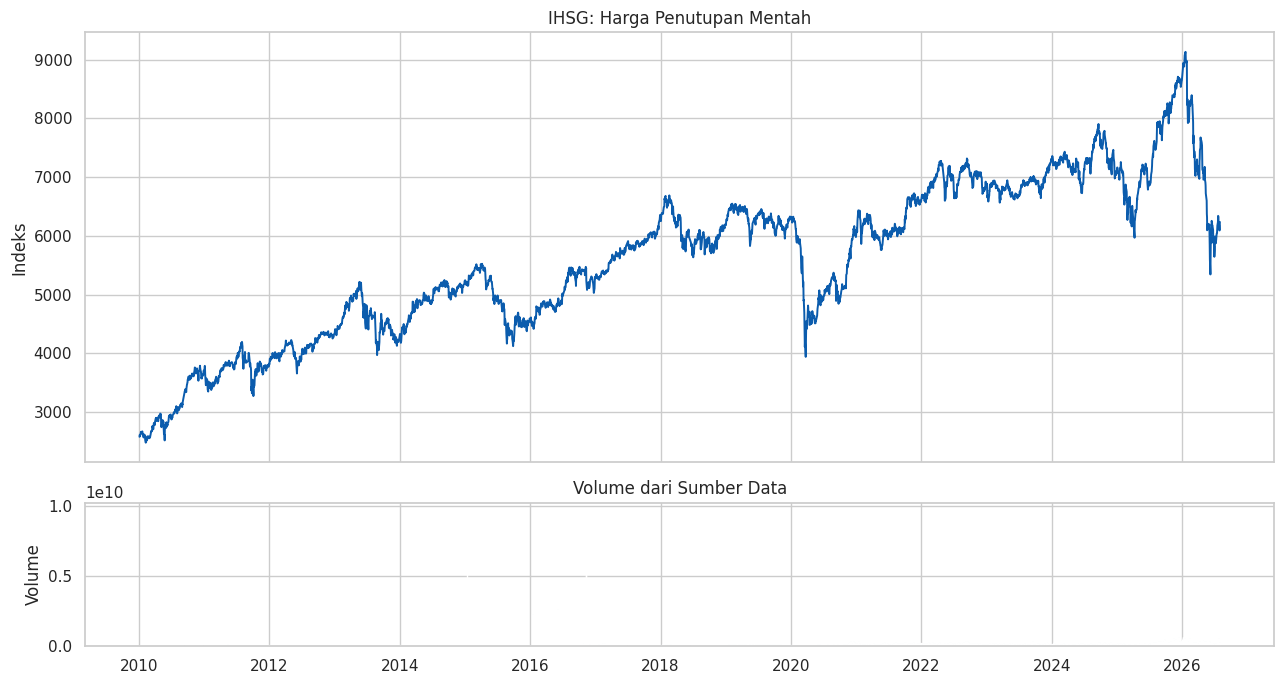

PosixPath('/kaggle/working/ihsg_audit_outputs/01_raw_ihsg.png')

In [5]:
# TAHAP 3 - Unduh data IHSG otomatis dan catat sumber
raw = download_ihsg(CONFIG["ticker"], CONFIG["start_date"], CONFIG["end_date"])
raw.to_csv(OUTPUT_DIR / "raw_ihsg.csv")

source_metadata = pd.DataFrame([
    ["Simbol", CONFIG["ticker"]],
    ["Sumber data", "Yahoo Finance melalui pustaka yfinance"],
    ["Dokumentasi", "https://ranaroussi.github.io/yfinance/reference/index.html"],
    ["Waktu unduh UTC", datetime.now(timezone.utc).isoformat()],
    ["Tanggal pertama", raw.index.min().date().isoformat()],
    ["Tanggal terakhir", raw.index.max().date().isoformat()],
    ["Jumlah baris", len(raw)],
    ["Catatan", "Sumber riset, bukan feed resmi Bursa Efek Indonesia"],
], columns=["Elemen", "Nilai"])
display(source_metadata)
source_metadata.to_csv(OUTPUT_DIR / "source_metadata.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(raw.index, raw["Close"], color="#0B5CAD", linewidth=1.4)
axes[0].set_title("IHSG: Harga Penutupan Mentah")
axes[0].set_ylabel("Indeks")
axes[1].bar(raw.index, raw["Volume"], color="#73A9D8", width=1.0)
axes[1].set_title("Volume dari Sumber Data")
axes[1].set_ylabel("Volume")
savefig("01_raw_ihsg.png")

,Pemeriksaan,Hasil,Interpretasi
0,Baris mentah,4020,Informasi
1,Tanggal duplikat,0,Harus 0 setelah pembersihan
2,Nilai kosong OHLCV,0,Dihapus pada kolom wajib
3,Nilai tak hingga,0,Diganti NaN lalu dihapus
4,Baris harga tidak logis,0,Dihapus
5,Baris bersih,4020,Harus cukup untuk rolling 200 hari
6,Hari sejak observasi terakhir,2,Periksa kalender bursa dan keterlambatan sumber
7,Volume nol,8,Tidak diimputasi; fitur volume dapat dikeluarkan


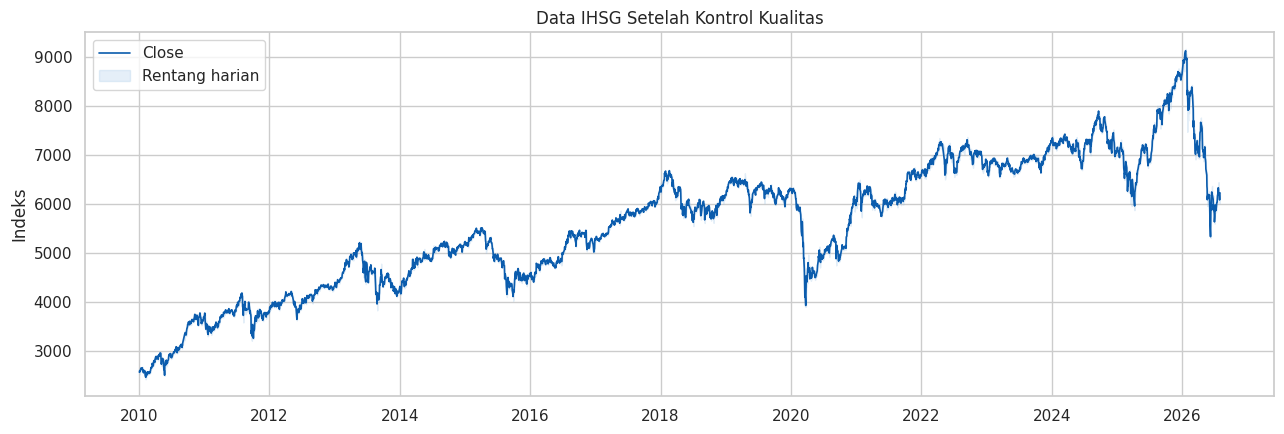

PosixPath('/kaggle/working/ihsg_audit_outputs/02_clean_ihsg.png')

In [6]:
# TAHAP 4 - Audit kualitas dan pembersihan data
required = ["Open", "High", "Low", "Close", "Volume"]
missing_columns = sorted(set(required) - set(raw.columns))
if missing_columns:
    raise ValueError(f"Kolom wajib tidak tersedia: {missing_columns}")

before_rows = len(raw)
duplicate_dates = int(raw.index.duplicated(keep=False).sum())
missing_before = int(raw[required].isna().sum().sum())
inf_before = int(np.isinf(raw[required].select_dtypes(include=np.number)).sum().sum())

data = raw.copy().sort_index()
data = data[~data.index.duplicated(keep="last")]
for col in required:
    data[col] = pd.to_numeric(data[col], errors="coerce")
data[required] = data[required].replace([np.inf, -np.inf], np.nan)

invalid_price = (
    (data[["Open", "High", "Low", "Close"]] <= 0).any(axis=1)
    | (data["High"] < data[["Open", "Close", "Low"]].max(axis=1))
    | (data["Low"] > data[["Open", "Close", "High"]].min(axis=1))
)
invalid_price_rows = int(invalid_price.sum())
data = data.loc[~invalid_price].dropna(subset=required)
after_rows = len(data)

stale_days = int((pd.Timestamp.now().normalize() - data.index.max()).days)
quality_report = pd.DataFrame([
    ["Baris mentah", before_rows, "Informasi"],
    ["Tanggal duplikat", duplicate_dates, "Harus 0 setelah pembersihan"],
    ["Nilai kosong OHLCV", missing_before, "Dihapus pada kolom wajib"],
    ["Nilai tak hingga", inf_before, "Diganti NaN lalu dihapus"],
    ["Baris harga tidak logis", invalid_price_rows, "Dihapus"],
    ["Baris bersih", after_rows, "Harus cukup untuk rolling 200 hari"],
    ["Hari sejak observasi terakhir", stale_days, "Periksa kalender bursa dan keterlambatan sumber"],
    ["Volume nol", int((data["Volume"] <= 0).sum()), "Tidak diimputasi; fitur volume dapat dikeluarkan"],
], columns=["Pemeriksaan", "Hasil", "Interpretasi"])
display(quality_report)
quality_report.to_csv(OUTPUT_DIR / "quality_report.csv", index=False)
data.to_csv(OUTPUT_DIR / "clean_ihsg.csv")

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(data.index, data["Close"], color="#0B5CAD", linewidth=1.2, label="Close")
ax.fill_between(data.index, data["Low"], data["High"], color="#99C2E6", alpha=0.25, label="Rentang harian")
ax.set_title("Data IHSG Setelah Kontrol Kualitas")
ax.set_ylabel("Indeks")
ax.legend()
savefig("02_clean_ihsg.png")

,Kontrol kebocoran,Nilai,Makna
0,Fitur memakai nilai setelah t,False,Semua rolling berakhir pada t
1,Target memakai sesi t+1,True,Hanya dipakai sebagai label dan return realisasi
2,Target masuk daftar fitur,False,Harus False
3,Future return masuk fitur,False,Harus False
4,Pengacakan data,False,Pembagian kronologis
5,Fitur volume dipakai,True,Otomatis dikeluarkan jika kualitas volume rendah


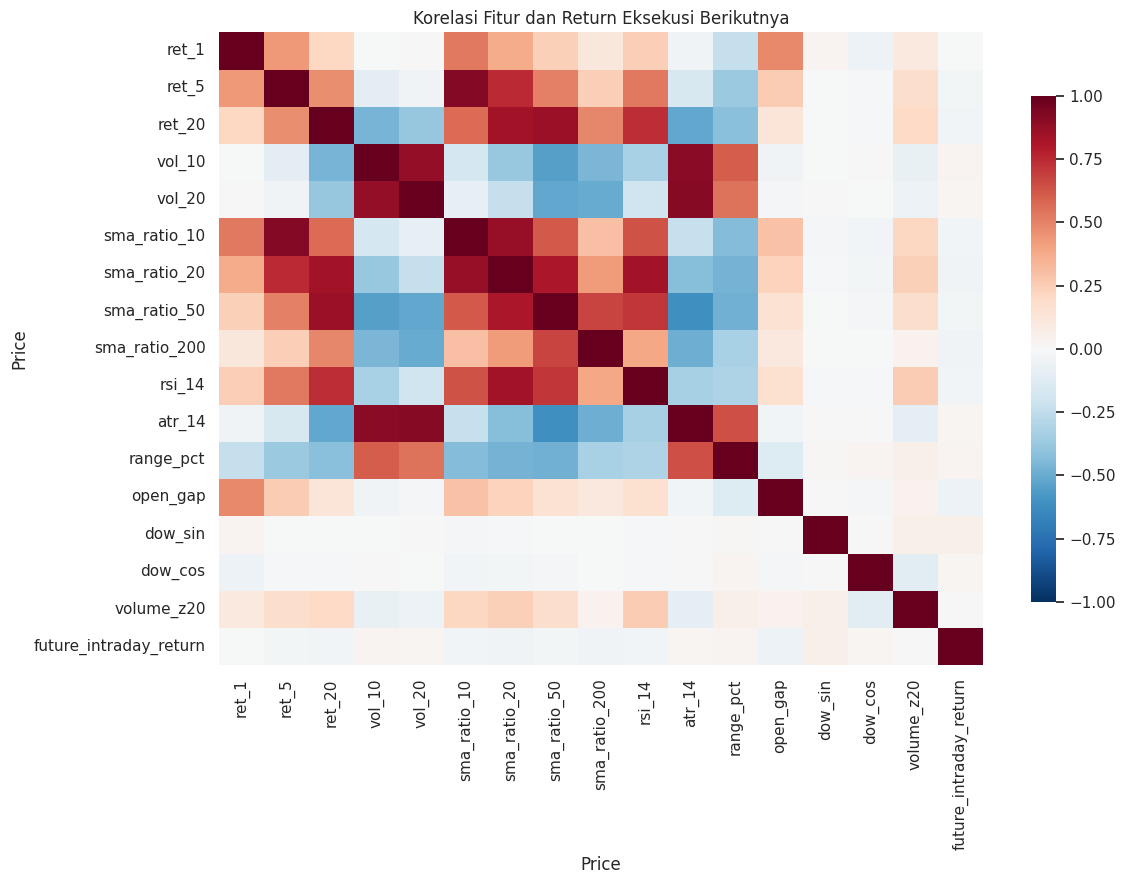

PosixPath('/kaggle/working/ihsg_audit_outputs/03_feature_correlation.png')

In [7]:
# TAHAP 5 - Rekayasa fitur tanpa informasi masa depan
df = data.copy()
df["ret_1"] = df["Close"].pct_change(1)
df["ret_5"] = df["Close"].pct_change(5)
df["ret_20"] = df["Close"].pct_change(20)
df["vol_10"] = df["ret_1"].rolling(10).std()
df["vol_20"] = df["ret_1"].rolling(20).std()
df["sma_ratio_10"] = df["Close"] / df["Close"].rolling(10).mean() - 1
df["sma_ratio_20"] = df["Close"] / df["Close"].rolling(20).mean() - 1
df["sma_ratio_50"] = df["Close"] / df["Close"].rolling(50).mean() - 1
df["sma_ratio_200"] = df["Close"] / df["Close"].rolling(200).mean() - 1
df["rsi_14"] = rsi(df["Close"], 14) / 100
true_range = pd.concat([
    df["High"] - df["Low"],
    (df["High"] - df["Close"].shift(1)).abs(),
    (df["Low"] - df["Close"].shift(1)).abs(),
], axis=1).max(axis=1)
df["atr_14"] = true_range.rolling(14).mean() / df["Close"]
df["range_pct"] = (df["High"] - df["Low"]) / df["Close"]
df["open_gap"] = df["Open"] / df["Close"].shift(1) - 1
df["dow_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 5)
df["dow_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 5)

volume_usable = (df["Volume"] > 0).mean() >= 0.80 and df["Volume"].nunique() > 20
if volume_usable:
    log_volume = np.log1p(df["Volume"])
    df["volume_z20"] = (log_volume - log_volume.rolling(20).mean()) / log_volume.rolling(20).std()

# Informasi pada baris t berhenti di Close(t). Eksekusi terjadi pada Open(t+1) sampai Close(t+1).
df["execution_date"] = pd.Series(df.index, index=df.index).shift(-1)
df["future_intraday_return"] = df["Close"].shift(-1) / df["Open"].shift(-1) - 1
df["target_up"] = (df["future_intraday_return"] > 0).astype(int)

FEATURES = [
    "ret_1", "ret_5", "ret_20", "vol_10", "vol_20",
    "sma_ratio_10", "sma_ratio_20", "sma_ratio_50", "sma_ratio_200",
    "rsi_14", "atr_14", "range_pct", "open_gap", "dow_sin", "dow_cos"
]
if volume_usable:
    FEATURES.append("volume_z20")

model_df = df.dropna(subset=FEATURES + ["future_intraday_return", "execution_date"]).copy()
model_df.to_csv(OUTPUT_DIR / "feature_dataset.csv")

leakage_audit = pd.DataFrame([
    ["Fitur memakai nilai setelah t", False, "Semua rolling berakhir pada t"],
    ["Target memakai sesi t+1", True, "Hanya dipakai sebagai label dan return realisasi"],
    ["Target masuk daftar fitur", "target_up" in FEATURES, "Harus False"],
    ["Future return masuk fitur", "future_intraday_return" in FEATURES, "Harus False"],
    ["Pengacakan data", False, "Pembagian kronologis"],
    ["Fitur volume dipakai", volume_usable, "Otomatis dikeluarkan jika kualitas volume rendah"],
], columns=["Kontrol kebocoran", "Nilai", "Makna"])
display(leakage_audit)

corr_cols = FEATURES + ["future_intraday_return"]
corr = model_df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Korelasi Fitur dan Return Eksekusi Berikutnya")
savefig("03_feature_correlation.png")

,Bagian,Baris,Mulai,Selesai,Proporsi Naik
0,Train,2674,2010-10-25,2021-10-14,0.5206
1,Validasi,573,2021-10-15,2024-02-21,0.5218
2,Test,573,2024-02-22,2026-07-30,0.4520


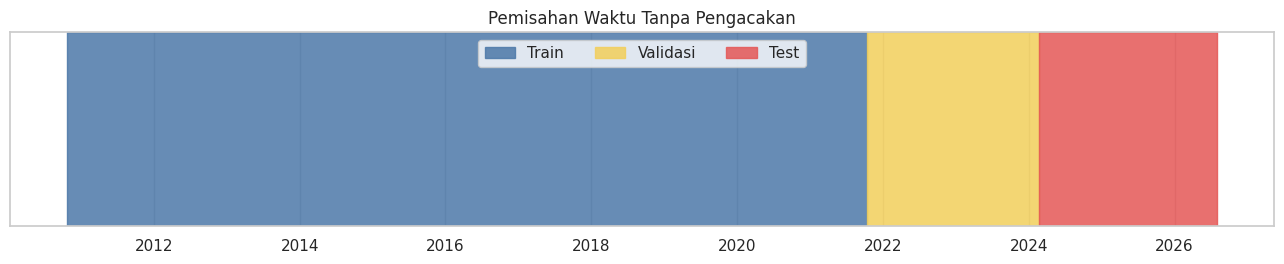

PosixPath('/kaggle/working/ihsg_audit_outputs/04_chronological_split.png')

In [8]:
# TAHAP 6 - Pembagian kronologis train, validasi, dan test
n = len(model_df)
train_end = int(n * CONFIG["train_fraction"])
valid_end = int(n * (CONFIG["train_fraction"] + CONFIG["validation_fraction"]))

train_df = model_df.iloc[:train_end].copy()
valid_df = model_df.iloc[train_end:valid_end].copy()
test_df = model_df.iloc[valid_end:].copy()

assert train_df.index.max() < valid_df.index.min() < test_df.index.min(), "Urutan waktu split gagal"
assert not set(train_df.index).intersection(valid_df.index), "Tanggal train dan validasi bertumpuk"
assert not set(valid_df.index).intersection(test_df.index), "Tanggal validasi dan test bertumpuk"

split_table = pd.DataFrame([
    ["Train", len(train_df), train_df.index.min().date(), train_df.index.max().date(), train_df["target_up"].mean()],
    ["Validasi", len(valid_df), valid_df.index.min().date(), valid_df.index.max().date(), valid_df["target_up"].mean()],
    ["Test", len(test_df), test_df.index.min().date(), test_df.index.max().date(), test_df["target_up"].mean()],
], columns=["Bagian", "Baris", "Mulai", "Selesai", "Proporsi Naik"])
display(split_table)
split_table.to_csv(OUTPUT_DIR / "chronological_split.csv", index=False)

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.axvspan(train_df.index.min(), train_df.index.max(), color="#4C78A8", alpha=0.85, label="Train")
ax.axvspan(valid_df.index.min(), valid_df.index.max(), color="#F2CF5B", alpha=0.85, label="Validasi")
ax.axvspan(test_df.index.min(), test_df.index.max(), color="#E45756", alpha=0.85, label="Test")
ax.set_yticks([])
ax.set_title("Pemisahan Waktu Tanpa Pengacakan")
ax.legend(ncol=3, loc="upper center")
savefig("04_chronological_split.png")

,Threshold,Cumulative Return,CAGR,Annual Volatility,Sharpe,Maximum Drawdown,Calmar,Trades,Exposure,Win Rate Active
0,0.500,-86.91%,-59.10%,9.76%,-9.091,-86.91%,-0.680067,439,76.61%,21.87%
1,0.525,-79.96%,-50.68%,9.07%,-7.734,-79.96%,-0.633877,334,58.29%,22.75%
2,0.550,-56.94%,-30.97%,6.88%,-5.348,-57.07%,-0.542574,181,31.59%,19.89%
3,0.575,-19.61%,-9.15%,4.05%,-2.351,-19.85%,-0.460993,58,10.12%,24.14%
4,0.600,-4.27%,-1.90%,1.73%,-1.099,-4.97%,-0.382314,14,2.44%,21.43%
5,0.625,-2.16%,-0.96%,1.05%,-0.914,-2.16%,-0.442483,2,0.35%,0.00%


Ambang terpilih hanya dari validasi: 0.575


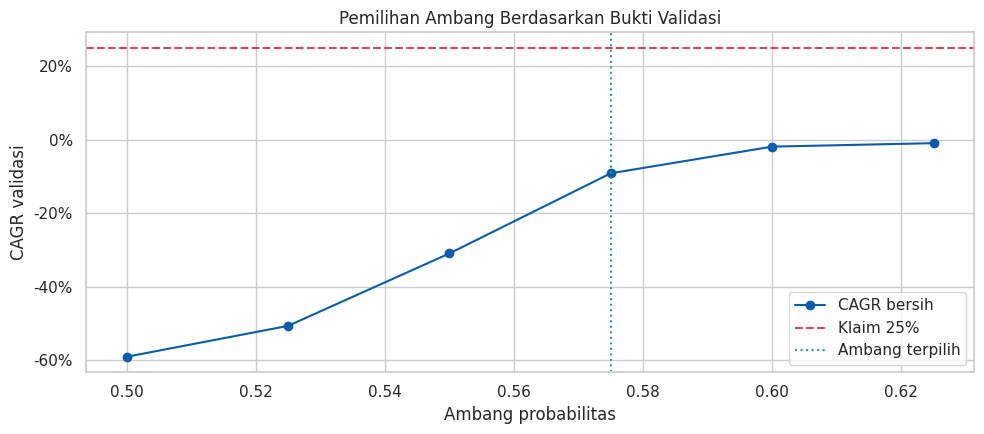

PosixPath('/kaggle/working/ihsg_audit_outputs/05_threshold_validation.png')

In [9]:
# TAHAP 7 - Pelatihan awal dan pemilihan ambang pada VALIDASI saja
def make_model(seed, n_estimators=400):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=6,
        min_samples_leaf=12,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=seed,
        n_jobs=-1,
    )

X_train, y_train = train_df[FEATURES], train_df["target_up"]
X_valid, y_valid = valid_df[FEATURES], valid_df["target_up"]
X_test, y_test = test_df[FEATURES], test_df["target_up"]

initial_model = make_model(SEED)
initial_model.fit(X_train, y_train)
valid_prob = initial_model.predict_proba(X_valid)[:, 1]

threshold_rows = []
for threshold in CONFIG["probability_threshold_grid"]:
    bt = backtest_from_prob(
        valid_prob, valid_df["future_intraday_return"],
        threshold, COST_BPS, cost_multiplier=1.0
    )
    m = performance_metrics(bt["net_return"], bt["signal"], CONFIG["annual_trading_days"])
    threshold_rows.append({"Threshold": threshold, **m})

threshold_table = pd.DataFrame(threshold_rows)
eligible = threshold_table[threshold_table["Trades"] >= max(20, int(len(valid_df) * 0.03))].copy()
if eligible.empty:
    raise RuntimeError("Tidak ada ambang dengan jumlah transaksi minimum. Periksa model dan data.")
BEST_THRESHOLD = float(eligible.sort_values(["Sharpe", "CAGR"], ascending=False).iloc[0]["Threshold"])

display(threshold_table.style.format({
    "Threshold": "{:.3f}", "Cumulative Return": "{:.2%}", "CAGR": "{:.2%}",
    "Annual Volatility": "{:.2%}", "Sharpe": "{:.3f}",
    "Maximum Drawdown": "{:.2%}", "Exposure": "{:.2%}", "Win Rate Active": "{:.2%}"
}).highlight_max(subset=["Sharpe"], color="#B7E4C7"))
print(f"Ambang terpilih hanya dari validasi: {BEST_THRESHOLD:.3f}")
threshold_table.to_csv(OUTPUT_DIR / "validation_thresholds.csv", index=False)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(threshold_table["Threshold"], threshold_table["CAGR"], marker="o", color="#0B5CAD", label="CAGR bersih")
ax1.axhline(CONFIG["claim_annual_return"], color="#D1495B", linestyle="--", label="Klaim 25%")
ax1.axvline(BEST_THRESHOLD, color="#2A9D8F", linestyle=":", label="Ambang terpilih")
ax1.set_xlabel("Ambang probabilitas")
ax1.set_ylabel("CAGR validasi")
ax1.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax1.set_title("Pemilihan Ambang Berdasarkan Bukti Validasi")
ax1.legend()
savefig("05_threshold_validation.png")

,Metrik,Nilai
0,Accuracy,0.5480
1,Balanced Accuracy,0.5057
2,Precision,0.5000
3,Recall,0.0656
4,F1,0.1160
5,ROC AUC,0.5058


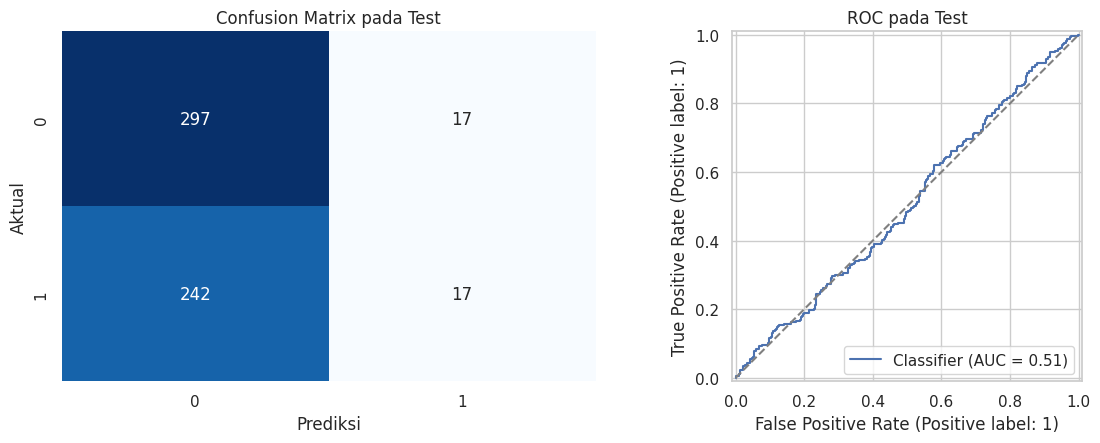

PosixPath('/kaggle/working/ihsg_audit_outputs/06_test_classification.png')

In [10]:
# TAHAP 8 - Model final dan evaluasi klasifikasi pada TEST
train_valid_df = pd.concat([train_df, valid_df]).sort_index()
X_train_valid = train_valid_df[FEATURES]
y_train_valid = train_valid_df["target_up"]

final_model = make_model(SEED)
final_model.fit(X_train_valid, y_train_valid)
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= BEST_THRESHOLD).astype(int)

class_metrics = pd.DataFrame([
    ["Accuracy", accuracy_score(y_test, test_pred)],
    ["Balanced Accuracy", balanced_accuracy_score(y_test, test_pred)],
    ["Precision", precision_score(y_test, test_pred, zero_division=0)],
    ["Recall", recall_score(y_test, test_pred, zero_division=0)],
    ["F1", f1_score(y_test, test_pred, zero_division=0)],
    ["ROC AUC", roc_auc_score(y_test, test_prob)],
], columns=["Metrik", "Nilai"])
display(class_metrics.style.format({"Nilai": "{:.4f}"}))
class_metrics.to_csv(OUTPUT_DIR / "classification_metrics.csv", index=False)

cm = confusion_matrix(y_test, test_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix pada Test")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")
RocCurveDisplay.from_predictions(y_test, test_prob, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC pada Test")
savefig("06_test_classification.png")

,Cumulative Return,CAGR,Annual Volatility,Sharpe,Maximum Drawdown,Calmar,Trades,Exposure,Win Rate Active
Kotor,-5.53%,-2.47%,8.29%,-0.261,-17.62%,-0.140,34,5.93%,50.00%
Bersih,-20.09%,-9.39%,8.61%,-1.102,-26.12%,-0.360,34,5.93%,17.65%


,Komponen,Basis point
0,komisi_beli_jual,24.0000
1,pajak_penjualan,10.0000
2,levy_bursa,4.0000
3,spread,3.0000
4,slippage,4.0000
5,penalti_likuiditas,2.0000
6,dampak_pasar,2.0000
7,Total per transaksi pulang-pergi,49.0000


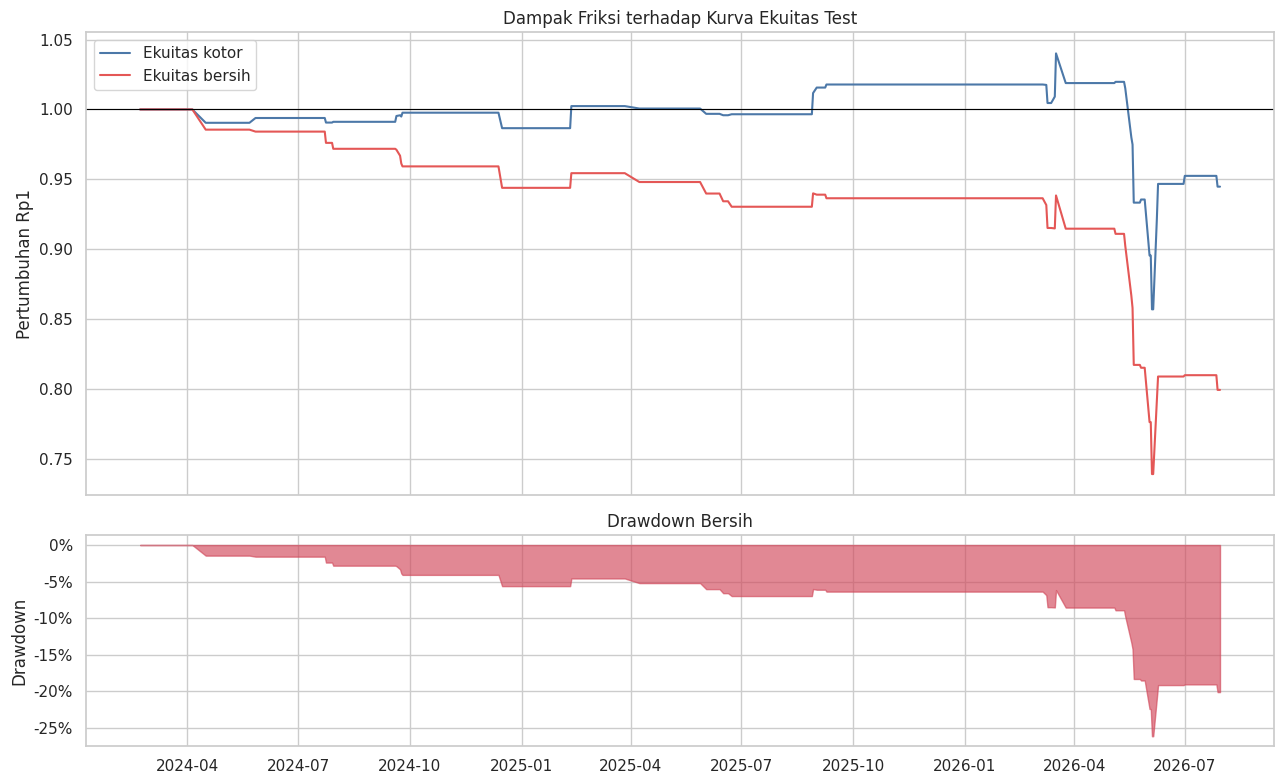

PosixPath('/kaggle/working/ihsg_audit_outputs/07_equity_and_drawdown.png')

In [11]:
# TAHAP 9 - Backtest kotor dan bersih setelah seluruh friksi
test_bt = backtest_from_prob(
    test_prob, test_df["future_intraday_return"],
    BEST_THRESHOLD, COST_BPS, cost_multiplier=1.0
)
test_bt["equity_gross"] = (1 + test_bt["gross_return"]).cumprod()
test_bt["equity_net"] = (1 + test_bt["net_return"]).cumprod()
test_bt["drawdown_net"] = test_bt["equity_net"] / test_bt["equity_net"].cummax() - 1

gross_metrics = performance_metrics(test_bt["gross_return"], test_bt["signal"])
net_metrics = performance_metrics(test_bt["net_return"], test_bt["signal"])
performance_table = pd.DataFrame([gross_metrics, net_metrics], index=["Kotor", "Bersih"])
display(performance_table.style.format({
    "Cumulative Return": "{:.2%}", "CAGR": "{:.2%}", "Annual Volatility": "{:.2%}",
    "Sharpe": "{:.3f}", "Maximum Drawdown": "{:.2%}", "Calmar": "{:.3f}",
    "Exposure": "{:.2%}", "Win Rate Active": "{:.2%}"
}))
performance_table.to_csv(OUTPUT_DIR / "test_performance.csv")
test_bt.to_csv(OUTPUT_DIR / "test_transactions.csv")

cost_table = pd.DataFrame({
    "Komponen": list(COST_BPS.keys()),
    "Basis point": list(COST_BPS.values()),
})
cost_table.loc[len(cost_table)] = ["Total per transaksi pulang-pergi", sum(COST_BPS.values())]
display(cost_table)
cost_table.to_csv(OUTPUT_DIR / "cost_assumptions.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
axes[0].plot(test_bt.index, test_bt["equity_gross"], label="Ekuitas kotor", color="#4C78A8")
axes[0].plot(test_bt.index, test_bt["equity_net"], label="Ekuitas bersih", color="#E45756")
axes[0].axhline(1, color="black", linewidth=0.8)
axes[0].set_title("Dampak Friksi terhadap Kurva Ekuitas Test")
axes[0].set_ylabel("Pertumbuhan Rp1")
axes[0].legend()
axes[1].fill_between(test_bt.index, test_bt["drawdown_net"], 0, color="#D1495B", alpha=0.65)
axes[1].set_title("Drawdown Bersih")
axes[1].set_ylabel("Drawdown")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
savefig("07_equity_and_drawdown.png")

,Threshold,Cost Multiplier,Total Cost bps,CAGR,Sharpe,Maximum Drawdown,Trades
0,0.500,0.000000,0.000000,-22.73%,-1.605,-48.95%,307
1,0.500,0.500000,24.500000,-44.55%,-3.690,-73.96%,307
2,0.500,1.000000,49.000000,-60.24%,-5.616,-87.70%,307
3,0.500,1.500000,73.500000,-71.52%,-7.327,-94.21%,307
4,0.500,2.000000,98.000000,-79.61%,-8.804,-97.28%,307
5,0.525,0.000000,0.000000,-18.41%,-1.527,-45.16%,204
6,0.525,0.500000,24.500000,-34.56%,-3.154,-65.17%,204
7,0.525,1.000000,49.000000,-47.54%,-4.609,-77.93%,204
8,0.525,1.500000,73.500000,-57.97%,-5.852,-86.14%,204
9,0.525,2.000000,98.000000,-66.35%,-6.882,-91.62%,204


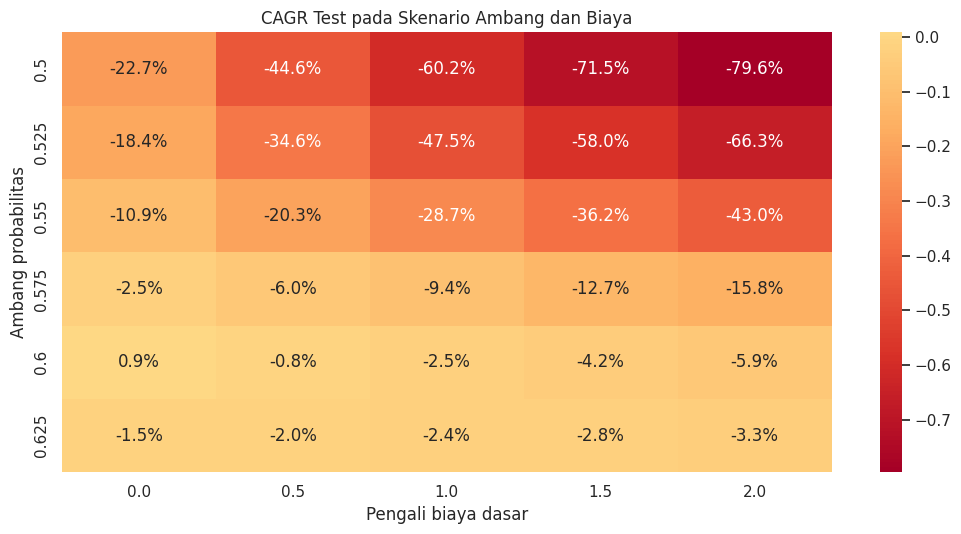

PosixPath('/kaggle/working/ihsg_audit_outputs/08_cost_threshold_stress.png')

In [12]:
# TAHAP 10 - Stress test biaya, ambang, dan klaim 25 persen
cost_multipliers = [0.0, 0.5, 1.0, 1.5, 2.0]
stress_rows = []
for threshold in CONFIG["probability_threshold_grid"]:
    for cost_multiplier in cost_multipliers:
        bt = backtest_from_prob(
            test_prob, test_df["future_intraday_return"],
            threshold, COST_BPS, cost_multiplier
        )
        m = performance_metrics(bt["net_return"], bt["signal"])
        stress_rows.append({
            "Threshold": threshold,
            "Cost Multiplier": cost_multiplier,
            "Total Cost bps": sum(COST_BPS.values()) * cost_multiplier,
            **m,
        })
stress_table = pd.DataFrame(stress_rows)
display(stress_table[["Threshold", "Cost Multiplier", "Total Cost bps", "CAGR", "Sharpe", "Maximum Drawdown", "Trades"]]
        .style.format({"Threshold": "{:.3f}", "CAGR": "{:.2%}", "Sharpe": "{:.3f}", "Maximum Drawdown": "{:.2%}"}))
stress_table.to_csv(OUTPUT_DIR / "cost_threshold_stress.csv", index=False)

pivot = stress_table.pivot(index="Threshold", columns="Cost Multiplier", values="CAGR")
fig, ax = plt.subplots(figsize=(10.5, 5.5))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn", center=CONFIG["claim_annual_return"], ax=ax)
ax.set_title("CAGR Test pada Skenario Ambang dan Biaya")
ax.set_xlabel("Pengali biaya dasar")
ax.set_ylabel("Ambang probabilitas")
savefig("08_cost_threshold_stress.png")

,Seed,Cumulative Return,CAGR,Annual Volatility,Sharpe,Maximum Drawdown,Calmar,Trades,Exposure,Win Rate Active
0,11,-24.34%,-11.55%,8.65%,-1.375,-28.47%,-0.405595,36,6.28%,13.89%
1,42,-21.03%,-9.86%,8.72%,-1.147,-27.50%,-0.358629,36,6.28%,19.44%
2,73,-28.40%,-13.67%,9.00%,-1.588,-32.23%,-0.424076,38,6.63%,13.16%
3,101,-23.21%,-10.97%,8.29%,-1.359,-27.31%,-0.401546,38,6.63%,15.79%
4,202,-17.48%,-8.10%,7.59%,-1.075,-21.88%,-0.370220,29,5.06%,13.79%


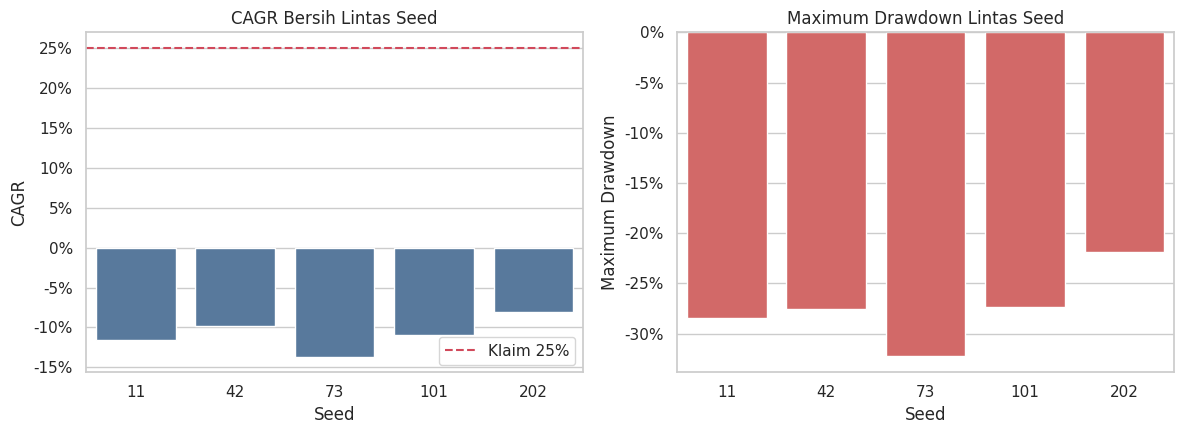

PosixPath('/kaggle/working/ihsg_audit_outputs/09_seed_stability.png')

In [13]:
# TAHAP 11 - Stabilitas lintas seed
seed_rows = []
seed_probabilities = {}
for seed in CONFIG["seeds"]:
    model_seed = make_model(seed, n_estimators=300)
    model_seed.fit(X_train_valid, y_train_valid)
    prob_seed = model_seed.predict_proba(X_test)[:, 1]
    seed_probabilities[seed] = prob_seed
    bt_seed = backtest_from_prob(
        prob_seed, test_df["future_intraday_return"],
        BEST_THRESHOLD, COST_BPS, cost_multiplier=1.0
    )
    m = performance_metrics(bt_seed["net_return"], bt_seed["signal"])
    seed_rows.append({"Seed": seed, **m})

seed_table = pd.DataFrame(seed_rows)
display(seed_table.style.format({
    "Cumulative Return": "{:.2%}", "CAGR": "{:.2%}", "Annual Volatility": "{:.2%}",
    "Sharpe": "{:.3f}", "Maximum Drawdown": "{:.2%}", "Exposure": "{:.2%}",
    "Win Rate Active": "{:.2%}"
}))
seed_table.to_csv(OUTPUT_DIR / "seed_stability.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=seed_table, x="Seed", y="CAGR", color="#4C78A8", ax=axes[0])
axes[0].axhline(CONFIG["claim_annual_return"], color="#D1495B", linestyle="--", label="Klaim 25%")
axes[0].set_title("CAGR Bersih Lintas Seed")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[0].legend()
sns.barplot(data=seed_table, x="Seed", y="Maximum Drawdown", color="#E45756", ax=axes[1])
axes[1].set_title("Maximum Drawdown Lintas Seed")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
savefig("09_seed_stability.png")

,Pemeriksaan,Hasil,Kriteria
0,Jumlah sampel SHAP,250,Informasi
1,Residual maksimum,0.0000,Target <= 1e-6
2,Residual rata-rata,0.0000,Mendekati 0
3,Skala yang direkonstruksi,Probabilitas kelas naik,"Sama dengan predict_proba[:,1]"
4,Interpretasi kausal,False,"SHAP menjelaskan model, bukan sebab-akibat"


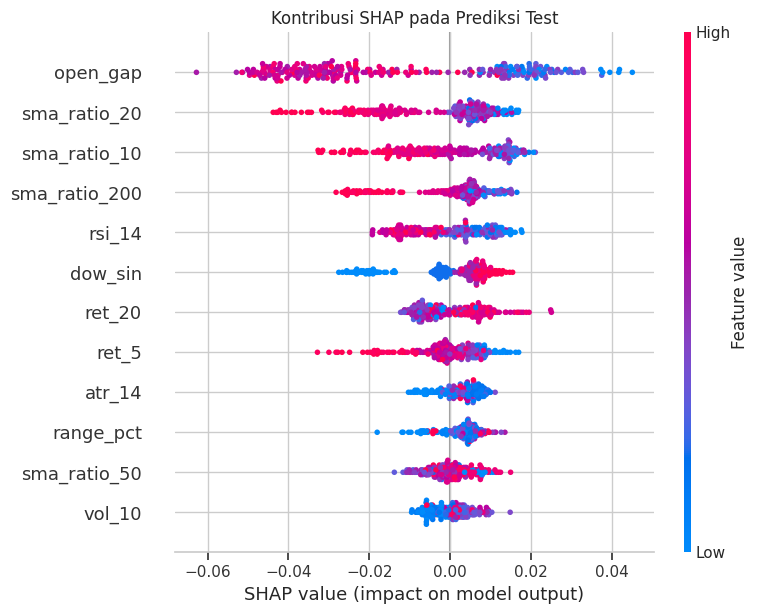

,11,42,73
open_gap,0.0287,0.0278,0.0284
sma_ratio_20,0.0134,0.0138,0.0123
rsi_14,0.0100,0.0082,0.0092
sma_ratio_10,0.0095,0.0119,0.0118
dow_sin,0.0084,0.0083,0.0091
sma_ratio_200,0.0081,0.0095,0.0103
ret_20,0.0071,0.0080,0.0075
ret_5,0.0067,0.0068,0.0059
atr_14,0.0053,0.0055,0.0038
range_pct,0.0048,0.0044,0.0050


,11,42,73
11,1.000,0.944,0.962
42,0.944,1.000,0.932
73,0.962,0.932,1.000


Rata-rata korelasi peringkat SHAP lintas seed: 0.946


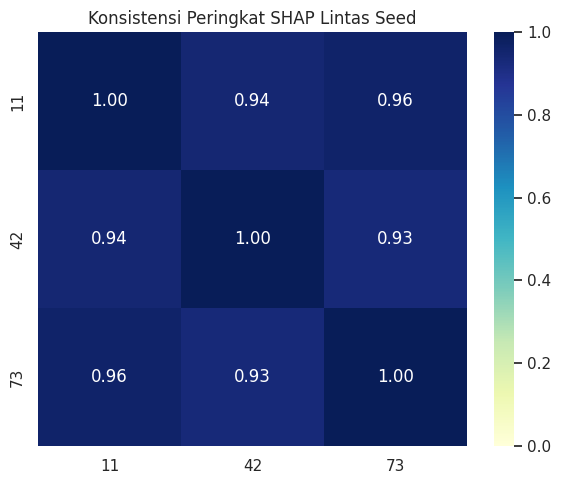

PosixPath('/kaggle/working/ihsg_audit_outputs/11_shap_stability.png')

In [14]:
# TAHAP 12 - SHAP, rekonstruksi output, dan kestabilan penjelasan
shap_sample = X_test.sample(n=min(250, len(X_test)), random_state=SEED).sort_index()
explainer = shap.TreeExplainer(final_model)
raw_shap = explainer.shap_values(shap_sample, check_additivity=False)

# Normalisasi format SHAP lintas versi: list per kelas, matriks 2D, atau tensor 3D.
if isinstance(raw_shap, list):
    shap_values = np.asarray(raw_shap[1] if len(raw_shap) > 1 else raw_shap[0])
else:
    raw_array = np.asarray(raw_shap)
    shap_values = raw_array[:, :, 1] if raw_array.ndim == 3 else raw_array

expected = np.asarray(explainer.expected_value)
base_value = float(expected.ravel()[1] if expected.size > 1 else expected.ravel()[0])
reconstructed_probability = base_value + shap_values.sum(axis=1)
actual_probability = final_model.predict_proba(shap_sample)[:, 1]
additivity_residual = np.abs(reconstructed_probability - actual_probability)

shap_audit = pd.DataFrame([
    ["Jumlah sampel SHAP", len(shap_sample), "Informasi"],
    ["Residual maksimum", float(additivity_residual.max()), "Target <= 1e-6"],
    ["Residual rata-rata", float(additivity_residual.mean()), "Mendekati 0"],
    ["Skala yang direkonstruksi", "Probabilitas kelas naik", "Sama dengan predict_proba[:,1]"],
    ["Interpretasi kausal", False, "SHAP menjelaskan model, bukan sebab-akibat"],
], columns=["Pemeriksaan", "Hasil", "Kriteria"])
display(shap_audit)
shap_audit.to_csv(OUTPUT_DIR / "shap_additivity_audit.csv", index=False)

plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values, shap_sample, show=False, max_display=12)
plt.title("Kontribusi SHAP pada Prediksi Test")
savefig("10_shap_summary.png")

# Stabilitas global SHAP pada tiga seed agar biaya komputasi tetap terkontrol.
shap_seed_rows = []
fixed_sample = X_test.sample(n=min(120, len(X_test)), random_state=17).sort_index()
for seed in CONFIG["seeds"][:3]:
    m_seed = make_model(seed, n_estimators=250)
    m_seed.fit(X_train_valid, y_train_valid)
    ex_seed = shap.TreeExplainer(m_seed)
    sv_seed_raw = ex_seed.shap_values(fixed_sample, check_additivity=False)
    if isinstance(sv_seed_raw, list):
        sv_seed = np.asarray(sv_seed_raw[1] if len(sv_seed_raw) > 1 else sv_seed_raw[0])
    else:
        arr_seed = np.asarray(sv_seed_raw)
        sv_seed = arr_seed[:, :, 1] if arr_seed.ndim == 3 else arr_seed
    importance = np.abs(sv_seed).mean(axis=0)
    shap_seed_rows.append(pd.Series(importance, index=FEATURES, name=str(seed)))

shap_stability = pd.concat(shap_seed_rows, axis=1)
rank_correlation = shap_stability.rank(ascending=False).corr(method="spearman")
mean_rank_corr = float(rank_correlation.where(~np.eye(len(rank_correlation), dtype=bool)).stack().mean())
display(shap_stability.sort_values(shap_stability.columns.tolist(), ascending=False).head(12))
display(rank_correlation.style.format("{:.3f}"))
print(f"Rata-rata korelasi peringkat SHAP lintas seed: {mean_rank_corr:.3f}")
shap_stability.to_csv(OUTPUT_DIR / "shap_seed_importance.csv")
rank_correlation.to_csv(OUTPUT_DIR / "shap_rank_correlation.csv")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(rank_correlation, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="YlGnBu", ax=ax)
ax.set_title("Konsistensi Peringkat SHAP Lintas Seed")
savefig("11_shap_stability.png")

,Periode,Cumulative Return,CAGR,Annual Volatility,Sharpe,Maximum Drawdown,Calmar,Trades,Exposure,Win Rate Active
0,2024,-5.62%,-6.92%,2.73%,-2.617,-5.62%,-1.232843,9,4.43%,0.000000
1,2025,-0.79%,-0.84%,2.10%,-0.393,-2.52%,-0.335012,8,3.39%,0.250000
2,2026,-14.66%,-25.77%,17.26%,-1.640,-21.26%,-1.212125,17,12.69%,0.235294


,Dimensi,Rezim,Cumulative Return,CAGR,Annual Volatility,Sharpe,Maximum Drawdown,Calmar,Trades,Exposure,Win Rate Active
0,Volatility Regime,Volatilitas rendah,-3.94%,-5.48%,2.20%,-2.545,-3.94%,-1.388872,7,3.89%,0.000000
1,Volatility Regime,Volatilitas tinggi,-16.81%,-11.13%,10.29%,-1.094,-23.08%,-0.482126,27,6.87%,0.222222
2,Trend Regime,Di atas SMA200,-3.45%,-2.72%,1.92%,-1.429,-4.08%,-0.666943,11,3.43%,0.090909
3,Trend Regime,Di bawah SMA200,-17.23%,-17.23%,12.80%,-1.413,-23.47%,-0.733956,23,9.13%,0.217391


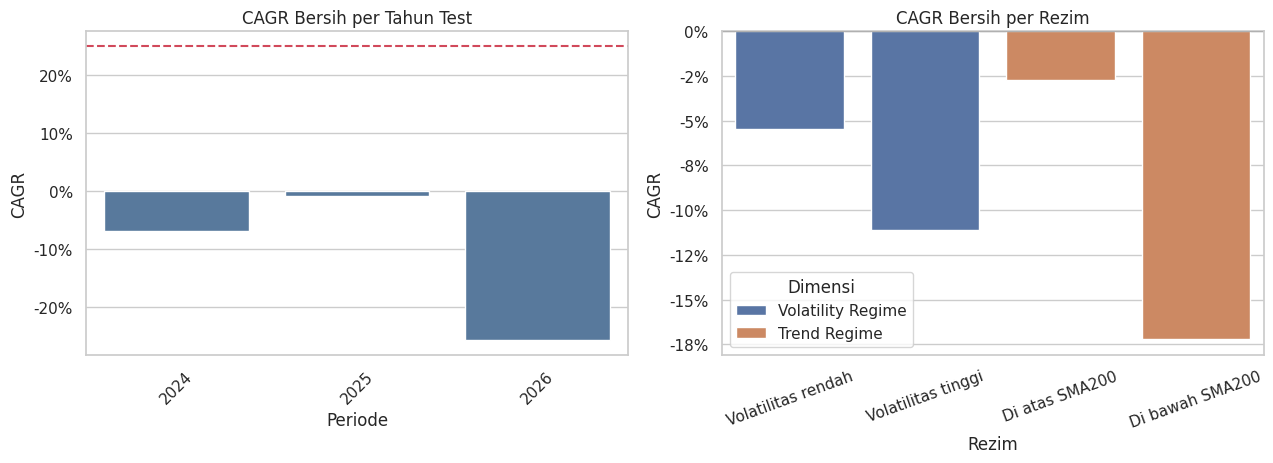

PosixPath('/kaggle/working/ihsg_audit_outputs/12_period_regime_stability.png')

In [15]:
# TAHAP 13 - Stabilitas per tahun dan rezim pasar
regime_df = test_df[["Close", "vol_20", "sma_ratio_200"]].copy()
regime_df = regime_df.join(test_bt[["signal", "net_return"]])
regime_df["Year"] = regime_df.index.year
median_vol = float(train_valid_df["vol_20"].median())
regime_df["Volatility Regime"] = np.where(regime_df["vol_20"] > median_vol, "Volatilitas tinggi", "Volatilitas rendah")
regime_df["Trend Regime"] = np.where(regime_df["sma_ratio_200"] >= 0, "Di atas SMA200", "Di bawah SMA200")

annual_rows = []
for year, group in regime_df.groupby("Year"):
    m = performance_metrics(group["net_return"], group["signal"])
    annual_rows.append({"Periode": str(year), **m})
annual_table = pd.DataFrame(annual_rows)

regime_rows = []
for dimension in ["Volatility Regime", "Trend Regime"]:
    for label, group in regime_df.groupby(dimension):
        m = performance_metrics(group["net_return"], group["signal"])
        regime_rows.append({"Dimensi": dimension, "Rezim": label, **m})
regime_table = pd.DataFrame(regime_rows)

display(annual_table.style.format({
    "Cumulative Return": "{:.2%}", "CAGR": "{:.2%}", "Annual Volatility": "{:.2%}",
    "Sharpe": "{:.3f}", "Maximum Drawdown": "{:.2%}", "Exposure": "{:.2%}"
}))
display(regime_table.style.format({
    "Cumulative Return": "{:.2%}", "CAGR": "{:.2%}", "Annual Volatility": "{:.2%}",
    "Sharpe": "{:.3f}", "Maximum Drawdown": "{:.2%}", "Exposure": "{:.2%}"
}))
annual_table.to_csv(OUTPUT_DIR / "annual_stability.csv", index=False)
regime_table.to_csv(OUTPUT_DIR / "regime_stability.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(data=annual_table, x="Periode", y="CAGR", color="#4C78A8", ax=axes[0])
axes[0].axhline(CONFIG["claim_annual_return"], color="#D1495B", linestyle="--")
axes[0].set_title("CAGR Bersih per Tahun Test")
axes[0].tick_params(axis="x", rotation=45)
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
sns.barplot(data=regime_table, x="Rezim", y="CAGR", hue="Dimensi", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("CAGR Bersih per Rezim")
axes[1].tick_params(axis="x", rotation=20)
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
savefig("12_period_regime_stability.png")

,Kontrol,Lolos,Bukti,Dampak jika gagal
0,Indeks tanggal monoton,True,True,Kritis
1,Tanggal unik,True,Duplikat: 0,Kritis
2,Train mendahului validasi,True,2021-10-14 < 2021-10-15,Kritis
3,Validasi mendahului test,True,2024-02-21 < 2024-02-22,Kritis
4,Target tidak menjadi fitur,True,"['ret_1', 'ret_5', 'ret_20', 'vol_10', 'vol_20', 'sma_ratio_10', 'sma_ratio_20', 'sma_ratio_50', 'sma_ratio_200', 'rsi_14', 'atr_14', 'range_pct', 'open_gap', 'dow_sin', 'dow_cos', 'volume_z20']",Kritis
5,Return masa depan tidak menjadi fitur,True,"['ret_1', 'ret_5', 'ret_20', 'vol_10', 'vol_20', 'sma_ratio_10', 'sma_ratio_20', 'sma_ratio_50', 'sma_ratio_200', 'rsi_14', 'atr_14', 'range_pct', 'open_gap', 'dow_sin', 'dow_cos', 'volume_z20']",Kritis
6,Eksekusi setelah tanggal sinyal,True,execution_date > signal_date,Kritis
7,Probabilitas valid,True,rentang 0.3315 sampai 0.6505,Kritis
8,Biaya tidak negatif,True,49.0 bps,Kritis
9,Biaya hanya saat aktif,True,biaya = 0 saat signal = 0,Kritis


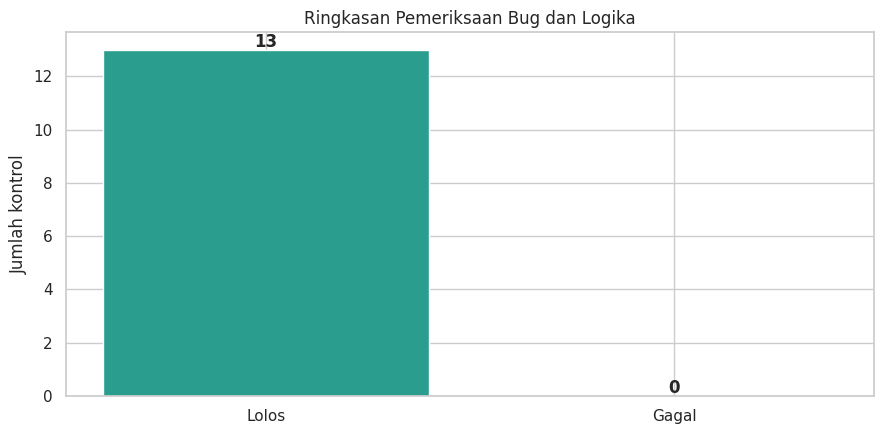

PosixPath('/kaggle/working/ihsg_audit_outputs/13_logic_checks.png')

In [16]:
# TAHAP 14 - Pemeriksaan error, bug, dan logika
checks = []
def add_check(name, passed, evidence, severity="Kritis"):
    checks.append({"Kontrol": name, "Lolos": bool(passed), "Bukti": evidence, "Dampak jika gagal": severity})

add_check("Indeks tanggal monoton", model_df.index.is_monotonic_increasing, str(model_df.index.is_monotonic_increasing))
add_check("Tanggal unik", model_df.index.is_unique, f"Duplikat: {model_df.index.duplicated().sum()}")
add_check("Train mendahului validasi", train_df.index.max() < valid_df.index.min(), f"{train_df.index.max().date()} < {valid_df.index.min().date()}")
add_check("Validasi mendahului test", valid_df.index.max() < test_df.index.min(), f"{valid_df.index.max().date()} < {test_df.index.min().date()}")
add_check("Target tidak menjadi fitur", "target_up" not in FEATURES, str(FEATURES))
add_check("Return masa depan tidak menjadi fitur", "future_intraday_return" not in FEATURES, str(FEATURES))
add_check("Eksekusi setelah tanggal sinyal", bool((model_df["execution_date"] > model_df.index).all()), "execution_date > signal_date")
add_check("Probabilitas valid", bool(((test_prob >= 0) & (test_prob <= 1)).all()), f"rentang {test_prob.min():.4f} sampai {test_prob.max():.4f}")
add_check("Biaya tidak negatif", roundtrip_cost_rate(COST_BPS) >= 0, f"{sum(COST_BPS.values()):.1f} bps")
add_check("Biaya hanya saat aktif", bool((test_bt.loc[test_bt["signal"] == 0, "transaction_cost"] == 0).all()), "biaya = 0 saat signal = 0")
add_check("Return bersih tidak melebihi kotor", bool((test_bt["net_return"] <= test_bt["gross_return"] + 1e-15).all()), "net = gross - cost")
add_check("Ekuitas finite", bool(np.isfinite(test_bt[["equity_gross", "equity_net"]]).all().all()), "Tidak ada NaN atau inf")
add_check("Aditivitas SHAP", float(additivity_residual.max()) <= 1e-6, f"residual maks {additivity_residual.max():.3e}")

logic_checks = pd.DataFrame(checks)
def color_boolean(v):
    return "background-color: #B7E4C7" if v is True else ("background-color: #F8B4B4" if v is False else "")
logic_style = logic_checks.style
logic_style = logic_style.map(color_boolean) if hasattr(logic_style, "map") else logic_style.applymap(color_boolean)
display(logic_style)
logic_checks.to_csv(OUTPUT_DIR / "logic_bug_checks.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
counts = logic_checks["Lolos"].value_counts().reindex([True, False], fill_value=0)
ax.bar(["Lolos", "Gagal"], counts.values, color=["#2A9D8F", "#D1495B"])
for i, value in enumerate(counts.values):
    ax.text(i, value + 0.1, str(value), ha="center", fontweight="bold")
ax.set_title("Ringkasan Pemeriksaan Bug dan Logika")
ax.set_ylabel("Jumlah kontrol")
savefig("13_logic_checks.png")

,Kriteria,Lolos,Bukti,Jenis
0,Integritas pipeline,True,Semua kontrol kode dan logika lolos,Wajib
1,CAGR kotor mencapai 25%,False,-2.47%,Diagnostik
2,CAGR bersih mencapai 25%,False,-9.39%,Wajib untuk klaim
3,"CAGR tetap positif saat biaya 1,5x",False,-12.68%,Stabilitas
4,MDD bersih tidak lebih buruk dari -20%,False,-26.12%,Batas risiko contoh
5,Minimal 70% tahun test positif,False,0.0%,Stabilitas
6,Simpangan CAGR seed <= 5 poin persen,True,2.06%,Reproduksibilitas
7,"Korelasi peringkat SHAP >= 0,70",True,0.946,Stabilitas penjelasan
8,Residual SHAP <= 1e-6,True,3.886e-15,Rekonstruksi


### Keputusan validator

**KLAIM 25% TIDAK TERVALIDASI: return bersih test berada di bawah klaim.**

,Area,Rekomendasi terbatas
0,Modal,"Batasi modal pilot, misalnya maksimum 1% angga..."
1,Instrumen,Uji pada instrumen yang benar-benar dapat dipe...
2,Frekuensi pemantauan,Harian untuk kualitas data dan eksekusi; mingg...
3,Indikator penghentian,"Stop bila MDD melewati 20%, data gagal, biaya ..."
4,Persetujuan,Setiap perluasan modal memerlukan validasi ind...
5,Batas SHAP,Gunakan SHAP untuk menjelaskan perilaku model....


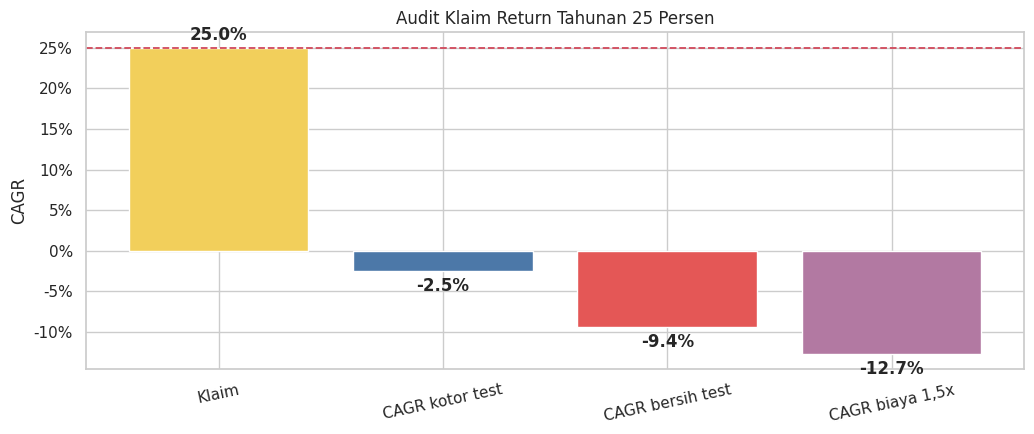

PosixPath('/kaggle/working/ihsg_audit_outputs/14_claim_audit.png')

In [17]:
# TAHAP 15 - Putusan audit klaim 25 persen
net_cagr = float(net_metrics["CAGR"])
gross_cagr = float(gross_metrics["CAGR"])
positive_year_share = float((annual_table["CAGR"] > 0).mean()) if len(annual_table) else 0.0
seed_cagr_std = float(seed_table["CAGR"].std(ddof=1))
stressed_row = stress_table[
    (np.isclose(stress_table["Threshold"], BEST_THRESHOLD))
    & (np.isclose(stress_table["Cost Multiplier"], 1.5))
].iloc[0]

criteria = pd.DataFrame([
    ["Integritas pipeline", bool(logic_checks["Lolos"].all()), "Semua kontrol kode dan logika lolos", "Wajib"],
    ["CAGR kotor mencapai 25%", gross_cagr >= CONFIG["claim_annual_return"], f"{gross_cagr:.2%}", "Diagnostik"],
    ["CAGR bersih mencapai 25%", net_cagr >= CONFIG["claim_annual_return"], f"{net_cagr:.2%}", "Wajib untuk klaim"],
    ["CAGR tetap positif saat biaya 1,5x", float(stressed_row["CAGR"]) > 0, f'{float(stressed_row["CAGR"]):.2%}', "Stabilitas"],
    ["MDD bersih tidak lebih buruk dari -20%", float(net_metrics["Maximum Drawdown"]) >= -0.20, f'{float(net_metrics["Maximum Drawdown"]):.2%}', "Batas risiko contoh"],
    ["Minimal 70% tahun test positif", positive_year_share >= 0.70, f"{positive_year_share:.1%}", "Stabilitas"],
    ["Simpangan CAGR seed <= 5 poin persen", seed_cagr_std <= 0.05, f"{seed_cagr_std:.2%}", "Reproduksibilitas"],
    ["Korelasi peringkat SHAP >= 0,70", mean_rank_corr >= 0.70, f"{mean_rank_corr:.3f}", "Stabilitas penjelasan"],
    ["Residual SHAP <= 1e-6", float(additivity_residual.max()) <= 1e-6, f"{float(additivity_residual.max()):.3e}", "Rekonstruksi"],
], columns=["Kriteria", "Lolos", "Bukti", "Jenis"])

if not bool(logic_checks["Lolos"].all()):
    decision = "TOLAK SEMENTARA: integritas pipeline belum lolos."
elif net_cagr < CONFIG["claim_annual_return"]:
    decision = "KLAIM 25% TIDAK TERVALIDASI: return bersih test berada di bawah klaim."
elif not bool(criteria.loc[criteria["Jenis"].isin(["Stabilitas", "Reproduksibilitas", "Stabilitas penjelasan"]), "Lolos"].all()):
    decision = "BUKTI BELUM STABIL: klaim belum layak menjadi dasar investasi penuh."
else:
    decision = "LAYAK UJI COBA TERBATAS: bukan persetujuan investasi penuh."

criteria_style = criteria.style
criteria_style = criteria_style.map(color_boolean) if hasattr(criteria_style, "map") else criteria_style.applymap(color_boolean)
display(criteria_style)
display(Markdown(f"### Keputusan validator\n\n**{decision}**"))
criteria.to_csv(OUTPUT_DIR / "audit_decision.csv", index=False)

recommendation = pd.DataFrame([
    ["Modal", "Batasi modal pilot, misalnya maksimum 1% anggaran strategi atau sesuai selera risiko komite"],
    ["Instrumen", "Uji pada instrumen yang benar-benar dapat diperdagangkan dan gunakan data bid-ask serta volume instrumen itu"],
    ["Frekuensi pemantauan", "Harian untuk kualitas data dan eksekusi; mingguan untuk kinerja; bulanan untuk validasi model"],
    ["Indikator penghentian", "Stop bila MDD melewati 20%, data gagal, biaya aktual > skenario 1,5x, atau drift material"],
    ["Persetujuan", "Setiap perluasan modal memerlukan validasi independen dan persetujuan Komite Investasi"],
    ["Batas SHAP", "Gunakan SHAP untuk menjelaskan perilaku model. Jangan menyatakan hubungan sebab-akibat"],
], columns=["Area", "Rekomendasi terbatas"])
display(recommendation)
recommendation.to_csv(OUTPUT_DIR / "limited_pilot_recommendation.csv", index=False)

fig, ax = plt.subplots(figsize=(10.5, 4.5))
comparison = pd.DataFrame({
    "Ukuran": ["Klaim", "CAGR kotor test", "CAGR bersih test", "CAGR biaya 1,5x"],
    "Nilai": [CONFIG["claim_annual_return"], gross_cagr, net_cagr, float(stressed_row["CAGR"])],
})
colors = ["#F2CF5B", "#4C78A8", "#E45756", "#B279A2"]
ax.bar(comparison["Ukuran"], comparison["Nilai"], color=colors)
ax.axhline(CONFIG["claim_annual_return"], color="#D1495B", linestyle="--", linewidth=1.3)
ax.set_title("Audit Klaim Return Tahunan 25 Persen")
ax.set_ylabel("CAGR")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.tick_params(axis="x", rotation=12)
for i, value in enumerate(comparison["Nilai"]):
    ax.text(i, value + (0.01 if value >= 0 else -0.025), f"{value:.1%}", ha="center", fontweight="bold")
savefig("14_claim_audit.png")

In [18]:
# TAHAP 16 - Executive summary, kontribusi anggota, dan daftar artefak
executive_summary = f"""EXECUTIVE SUMMARY AUDIT INDEPENDEN IHSG

Keputusan: {decision}

Data: {CONFIG['ticker']} dari {data.index.min().date()} sampai {data.index.max().date()}.
Periode test: {test_df.index.min().date()} sampai {test_df.index.max().date()}.
Ambang sinyal: {BEST_THRESHOLD:.3f}, dipilih hanya pada data validasi.
Biaya dasar: {sum(COST_BPS.values()):.1f} bps per transaksi pulang-pergi.
CAGR kotor test: {gross_cagr:.2%}.
CAGR bersih test: {net_cagr:.2%}.
Maximum drawdown bersih: {float(net_metrics['Maximum Drawdown']):.2%}.
Proporsi tahun positif: {positive_year_share:.1%}.
Simpangan CAGR lintas seed: {seed_cagr_std:.2%}.
Korelasi peringkat SHAP lintas seed: {mean_rank_corr:.3f}.
Residual maksimum rekonstruksi SHAP: {float(additivity_residual.max()):.3e}.

Batas klaim: IHSG tidak dapat diperdagangkan langsung. Hasil belum boleh dipindahkan ke modal nyata sebelum biaya, spread, slippage, likuiditas, pajak, dan dampak pasar dihitung ulang memakai instrumen eksekusi yang sebenarnya.
"""
(OUTPUT_DIR / "executive_summary.txt").write_text(executive_summary, encoding="utf-8")
print(executive_summary)

contribution_template = pd.DataFrame([
    ["Anggota 1", "Audit sumber dan kualitas data", "Isi file, sel, atau pemeriksaan", "Isi hasil verifikasi", "Belum diisi"],
    ["Anggota 2", "Audit leakage dan pemisahan waktu", "Isi file, sel, atau pemeriksaan", "Isi hasil verifikasi", "Belum diisi"],
    ["Anggota 3", "Audit biaya dan backtest", "Isi file, sel, atau pemeriksaan", "Isi hasil verifikasi", "Belum diisi"],
    ["Anggota 4", "Audit SHAP dan stabilitas", "Isi file, sel, atau pemeriksaan", "Isi hasil verifikasi", "Belum diisi"],
    ["Anggota 5", "Laporan dan presentasi", "Isi halaman atau slide", "Isi bukti konsistensi", "Belum diisi"],
], columns=["Nama", "Peran", "Bukti kontribusi", "Hasil review", "Status"])
display(contribution_template)
contribution_template.to_csv(OUTPUT_DIR / "member_contributions_template.csv", index=False)

manifest = pd.DataFrame({
    "File output": sorted([p.name for p in OUTPUT_DIR.iterdir()]),
})
display(manifest)
print("Semua keluaran berasal dari satu eksekusi notebook ini. Unduh folder ihsg_audit_outputs dari panel Output Kaggle.")

EXECUTIVE SUMMARY AUDIT INDEPENDEN IHSG

Keputusan: KLAIM 25% TIDAK TERVALIDASI: return bersih test berada di bawah klaim.

Data: ^JKSE dari 2010-01-04 sampai 2026-07-31.
Periode test: 2024-02-22 sampai 2026-07-30.
Ambang sinyal: 0.575, dipilih hanya pada data validasi.
Biaya dasar: 49.0 bps per transaksi pulang-pergi.
CAGR kotor test: -2.47%.
CAGR bersih test: -9.39%.
Maximum drawdown bersih: -26.12%.
Proporsi tahun positif: 0.0%.
Simpangan CAGR lintas seed: 2.06%.
Korelasi peringkat SHAP lintas seed: 0.946.
Residual maksimum rekonstruksi SHAP: 3.886e-15.

Batas klaim: IHSG tidak dapat diperdagangkan langsung. Hasil belum boleh dipindahkan ke modal nyata sebelum biaya, spread, slippage, likuiditas, pajak, dan dampak pasar dihitung ulang memakai instrumen eksekusi yang sebenarnya.



,Nama,Peran,Bukti kontribusi,Hasil review,Status
0,Anggota 1,Audit sumber dan kualitas data,"Isi file, sel, atau pemeriksaan",Isi hasil verifikasi,Belum diisi
1,Anggota 2,Audit leakage dan pemisahan waktu,"Isi file, sel, atau pemeriksaan",Isi hasil verifikasi,Belum diisi
2,Anggota 3,Audit biaya dan backtest,"Isi file, sel, atau pemeriksaan",Isi hasil verifikasi,Belum diisi
3,Anggota 4,Audit SHAP dan stabilitas,"Isi file, sel, atau pemeriksaan",Isi hasil verifikasi,Belum diisi
4,Anggota 5,Laporan dan presentasi,Isi halaman atau slide,Isi bukti konsistensi,Belum diisi


,File output
0,01_raw_ihsg.png
1,02_clean_ihsg.png
2,03_feature_correlation.png
3,04_chronological_split.png
4,05_threshold_validation.png
5,06_test_classification.png
6,07_equity_and_drawdown.png
7,08_cost_threshold_stress.png
8,09_seed_stability.png
9,10_shap_summary.png


Semua keluaran berasal dari satu eksekusi notebook ini. Unduh folder ihsg_audit_outputs dari panel Output Kaggle.


## Analisis Kritis dan Cara Membaca Hasil

Klaim 25 persen harus memiliki definisi yang tegas. Notebook ini menafsirkannya sebagai CAGR tahunan. Return kumulatif selama beberapa tahun tidak boleh dibandingkan langsung dengan angka tahunan. Kolom kotor menjawab kemampuan sinyal sebelum friksi. Kolom bersih lebih dekat pada dampak ekonomi. Jika selisih keduanya besar, strategi terlalu bergantung pada transaksi yang sering atau keunggulan prediksinya terlalu kecil.

Akurasi tidak menjadi dasar keputusan investasi. Model dapat sering menebak arah dengan benar, tetapi rugi jika keuntungan saat benar lebih kecil daripada kerugian dan biaya saat salah. CAGR, Sharpe, MDD, jumlah transaksi, serta stabilitas tahunan harus dibaca bersama. Hasil satu *seed* juga belum cukup. Penyebaran besar lintas *seed* menandakan keputusan model sensitif terhadap variasi proses pelatihan.

SHAP menjelaskan fitur yang mendorong keluaran model. Residual rekonstruksi kecil membuktikan bahwa nilai SHAP cocok dengan keluaran komputasi yang dijelaskan. Korelasi peringkat lintas *seed* menilai kestabilan penjelasan global. Dua hasil itu tetap tidak membuktikan sebab-akibat ekonomi. Fitur dapat menjadi proksi atau bergerak bersama faktor lain.

Uji biaya memakai proksi karena data indeks tidak menyediakan antrean bid-ask yang dapat dieksekusi. Komite harus meminta backtest ulang pada instrumen aktual. Jika return turun tajam saat biaya dinaikkan 1,5 kali, margin keselamatan lemah. Putusan yang bertanggung jawab ialah menolak klaim, meminta validasi tambahan, atau menjalankan pilot bermodal kecil dengan indikator penghentian. Notebook tidak pernah mengubah hasil yang lemah menjadi rekomendasi investasi penuh.

## Daftar Risiko Bug yang Diantisipasi

| Risiko | Gejala | Kontrol program |
|---|---|---|
| Internet Kaggle mati | Data kosong | Pesan diagnostik dan penghentian aman |
| Kolom `MultiIndex` dari `yfinance` | Nama kolom tidak cocok | Normalisasi level kolom |
| Kebocoran target | Hasil terlalu tinggi | Daftar fitur eksplisit dan assertions |
| Split acak | Masa depan masuk train | Split indeks kronologis |
| Salah waktu eksekusi | Fitur dan return berada pada hari sama | `execution_date > signal_date` |
| Biaya dihitung saat tidak bertransaksi | Return bersih terlalu rendah | Biaya nol saat sinyal nol |
| Format SHAP berubah | Dimensi tidak cocok | Normalisasi list, 2D, dan 3D |
| Salah tafsir SHAP | Klaim kausal palsu | Pernyataan batas pada laporan |
| Volume indeks tidak layak | Likuiditas tampak presisi palsu | Fitur volume otomatis dikeluarkan dan biaya dinyatakan proksi |
| Klaim 25% tanpa horizon | Perbandingan salah | Klaim didefinisikan sebagai CAGR |

## Referensi Teknis

- yfinance. *API Reference*. https://ranaroussi.github.io/yfinance/reference/index.html
- SHAP. *TreeExplainer documentation*. https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html
- scikit-learn. *TimeSeriesSplit documentation*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html

Data Yahoo Finance melalui `yfinance` cocok untuk riset dan pembelajaran. Data tersebut bukan pengganti feed resmi bursa, data order book, atau konfirmasi transaksi broker.